# Module 11 Challenge
## Deliverable 2: Scrape and Analyze Mars Weather Data

In [1]:
# Import relevant libraries
from splinter import Browser
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
browser = Browser('chrome')

### Step 1: Visit the Website

Use automated browsing to visit the [Mars Temperature Data Site](https://static.bc-edx.com/data/web/mars_facts/temperature.html). Inspect the page to identify which elements to scrape.

   > **Hint** To identify which elements to scrape, you might want to inspect the page by using Chrome DevTools to discover whether the table contains usable classes.


In [3]:
# Visit the website
# https://static.bc-edx.com/data/web/mars_facts/temperature.html
url = "https://static.bc-edx.com/data/web/mars_facts/temperature.html"
browser.visit(url)

### Step 2: Scrape the Table

Create a Beautiful Soup object and use it to scrape the data in the HTML table.

Note that this can also be achieved by using the Pandas `read_html` function. However, use Beautiful Soup here to continue sharpening your web scraping skills.

In [4]:
# Save the HTML from the browser
html = browser.html

# Create a Beautiful Soup Object
soup = BeautifulSoup(html, 'html.parser')

In [6]:
# Extract all rows of data
table = soup.find("table", {"class": "table"})

### Step 3: Store the Data

Assemble the scraped data into a Pandas DataFrame. The columns should have the same headings as the table on the website. Here’s an explanation of the column headings:

* `id`: the identification number of a single transmission from the Curiosity rover
* `terrestrial_date`: the date on Earth
* `sol`: the number of elapsed sols (Martian days) since Curiosity landed on Mars
* `ls`: the solar longitude
* `month`: the Martian month
* `min_temp`: the minimum temperature, in Celsius, of a single Martian day (sol)
* `pressure`: The atmospheric pressure at Curiosity's location

In [7]:
# Create an empty list
data = []



In [9]:
# Loop through each row in the table
for row in table.find_all('tr')[1:]:  
    cols = row.find_all('td')  
    
    # Create a Pandas DataFrame by using the list of rows and a list of the column names
    if len(cols) == 7:
        data.append({
            'id': cols[0].text.strip(),
            'terrestrial_date': cols[1].text.strip(),
            'sol': cols[2].text.strip(),
            'ls': cols[3].text.strip(),
            'month': cols[4].text.strip(),
            'min_temp': cols[5].text.strip(),
            'pressure': cols[6].text.strip()
        })

# Define the column names (matching the dictionary keys)
columns = ['id', 'terrestrial_date', 'sol', 'ls', 'month', 'min_temp', 'pressure']

# Create a Pandas DataFrame using the data list and the column names
df = pd.DataFrame(data, columns=columns)

# Confirm DataFrame was created successfully
print(df)

        id terrestrial_date   sol   ls month min_temp pressure
0        2       2012-08-16    10  155     6    -75.0    739.0
1       13       2012-08-17    11  156     6    -76.0    740.0
2       24       2012-08-18    12  156     6    -76.0    741.0
3       35       2012-08-19    13  157     6    -74.0    732.0
4       46       2012-08-20    14  157     6    -74.0    740.0
...    ...              ...   ...  ...   ...      ...      ...
3729  1889       2018-02-23  1973  133     5    -78.0    730.0
3730  1892       2018-02-24  1974  134     5    -77.0    729.0
3731  1894       2018-02-25  1975  134     5    -76.0    729.0
3732  1893       2018-02-26  1976  135     5    -77.0    728.0
3733  1895       2018-02-27  1977  135     5    -77.0    727.0

[3734 rows x 7 columns]


### Step 4: Prepare Data for Analysis

Examine the data types that are currently associated with each column. If necessary, cast (or convert) the data to the appropriate `datetime`, `int`, or `float` data types.

  > **Hint** You can use the Pandas `astype` and `to_datetime` methods to accomplish this task.


In [11]:
# Examine data type of each column
df['terrestrial_date'] = pd.to_datetime(df['terrestrial_date'], errors='coerce')

# Change data types for data analysis (Convert 'sol', 'ls', 'month' to integers)
df['sol'] = pd.to_numeric(df['sol'], errors='coerce', downcast='integer')
df['ls'] = pd.to_numeric(df['ls'], errors='coerce', downcast='integer')
df['month'] = pd.to_numeric(df['month'], errors='coerce', downcast='integer')

# Convert 'min_temp' and 'pressure' to floats
df['min_temp'] = pd.to_numeric(df['min_temp'], errors='coerce', downcast='float')
df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce', downcast='float')

# Confirm type changes were successful by examining data types again
print("\nData types after conversion:")
print(df.dtypes)


Data types after conversion:
id                          object
terrestrial_date    datetime64[ns]
sol                          int16
ls                           int16
month                         int8
min_temp                   float32
pressure                   float32
dtype: object


### Step 5: Analyze the Data

Analyze your dataset by using Pandas functions to answer the following questions:

1. How many months exist on Mars?
2. How many Martian (and not Earth) days worth of data exist in the scraped dataset?
3. What are the coldest and the warmest months on Mars (at the location of Curiosity)? To answer this question:
    * Find the average the minimum daily temperature for all of the months.
    * Plot the results as a bar chart.
4. Which months have the lowest and the highest atmospheric pressure on Mars? To answer this question:
    * Find the average the daily atmospheric pressure of all the months.
    * Plot the results as a bar chart.
5. About how many terrestrial (Earth) days exist in a Martian year? To answer this question:
    * Consider how many days elapse on Earth in the time that Mars circles the Sun once.
    * Visually estimate the result by plotting the daily minimum temperature.


In [12]:
# 1. How many months are there on Mars?
num_months = df['month'].nunique()
print(f"Number of unique months on Mars: {num_months}")

Number of unique months on Mars: 12


In [13]:
# 2. How many sols (Martian days) worth of data are there?
num_sols = df['sol'].nunique()
print(f"Number of Martian days (sols) in the dataset: {num_sols}")

Number of Martian days (sols) in the dataset: 1867


In [18]:
# 3. What is the average minimum temperature by month?
avg_min_temp_by_month = df.groupby('month')['min_temp'].mean()
avg_min_temp_by_month

month
1    -77.160919
2    -79.932587
3    -83.307289
4    -82.747421
5    -79.308723
6    -75.299316
7    -72.281693
8    -68.382980
9    -69.171638
10   -71.982140
11   -71.985504
12   -74.451805
Name: min_temp, dtype: float32

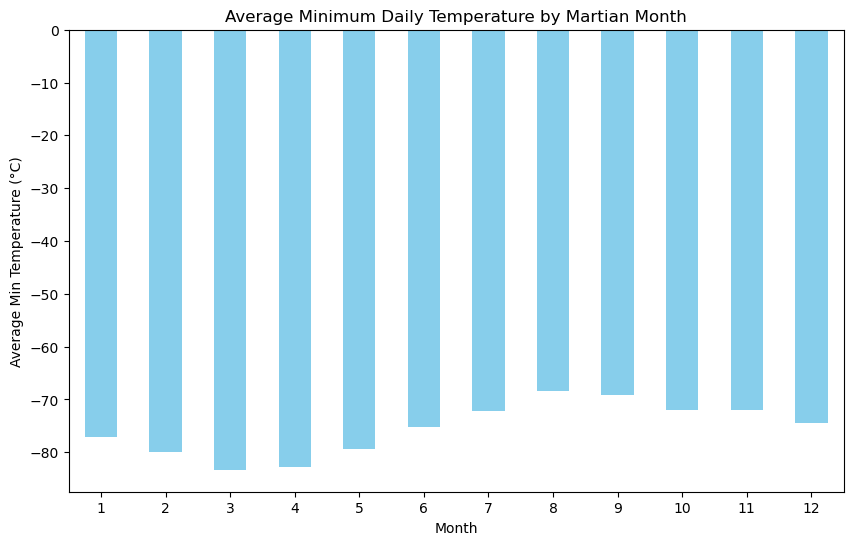

In [19]:
# Plot the average minimum temperature by month
plt.figure(figsize=(10, 6))
avg_min_temp_by_month.plot(kind='bar', color='skyblue')
plt.title('Average Minimum Daily Temperature by Martian Month')
plt.xlabel('Month')
plt.ylabel('Average Min Temperature (°C)')
plt.xticks(rotation=0)
plt.show()

In [20]:
# Identify the coldest and hottest months in Curiosity's location by sorting the previous graph
coldest_month = avg_min_temp_by_month.idxmin()
warmest_month = avg_min_temp_by_month.idxmax()
print(f"The coldest month is Month {coldest_month} with an average temperature of {avg_min_temp_by_month[coldest_month]}°C")
print(f"The warmest month is Month {warmest_month} with an average temperature of {avg_min_temp_by_month[warmest_month]}°C")

The coldest month is Month 3 with an average temperature of -83.30728912353516°C
The warmest month is Month 8 with an average temperature of -68.38298034667969°C


In [21]:
# 4. What is the average pressure by month?
avg_pressure_by_month = df.groupby('month')['pressure'].mean()
avg_pressure_by_month

month
1     862.488525
2     889.455078
3     877.322937
4     806.329895
5     748.557068
6     745.054443
7     795.105652
8     873.829773
9     913.305969
10    887.312500
11    857.014465
12    842.156616
Name: pressure, dtype: float32

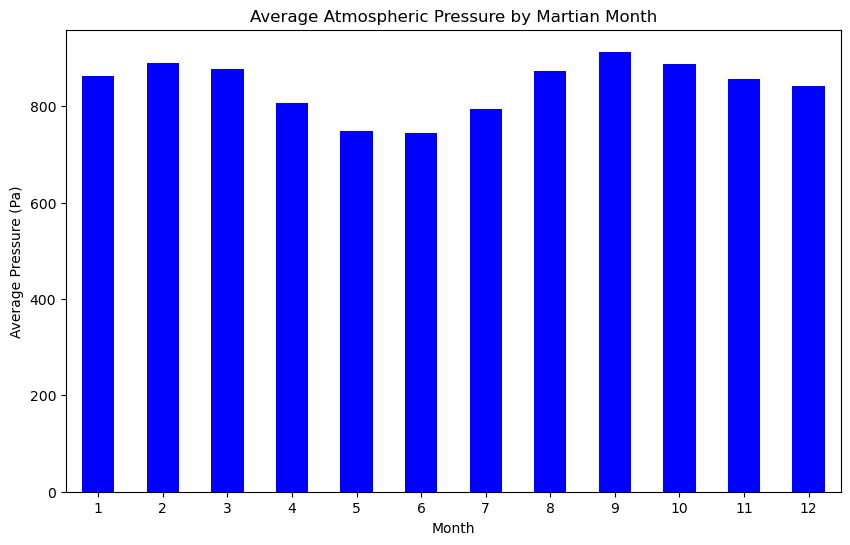

In [25]:
# Plot the average pressure by month
plt.figure(figsize=(10, 6))
avg_pressure_by_month.plot(kind='bar', color='blue')
plt.title('Average Atmospheric Pressure by Martian Month')
plt.xlabel('Month')
plt.ylabel('Average Pressure (Pa)')
plt.xticks(rotation=0)
plt.show()

In [23]:
# Identify the lowest and highest pressure months in Curiosity's location by sorting the previous graph
lowest_pressure_month = avg_pressure_by_month.idxmin()
highest_pressure_month = avg_pressure_by_month.idxmax()
print(f"The month with the lowest atmospheric pressure is Month {lowest_pressure_month} with an average pressure of {avg_pressure_by_month[lowest_pressure_month]} Pa")
print(f"The month with the highest atmospheric pressure is Month {highest_pressure_month} with an average pressure of {avg_pressure_by_month[highest_pressure_month]} Pa")

The month with the lowest atmospheric pressure is Month 6 with an average pressure of 745.054443359375 Pa
The month with the highest atmospheric pressure is Month 9 with an average pressure of 913.3059692382812 Pa


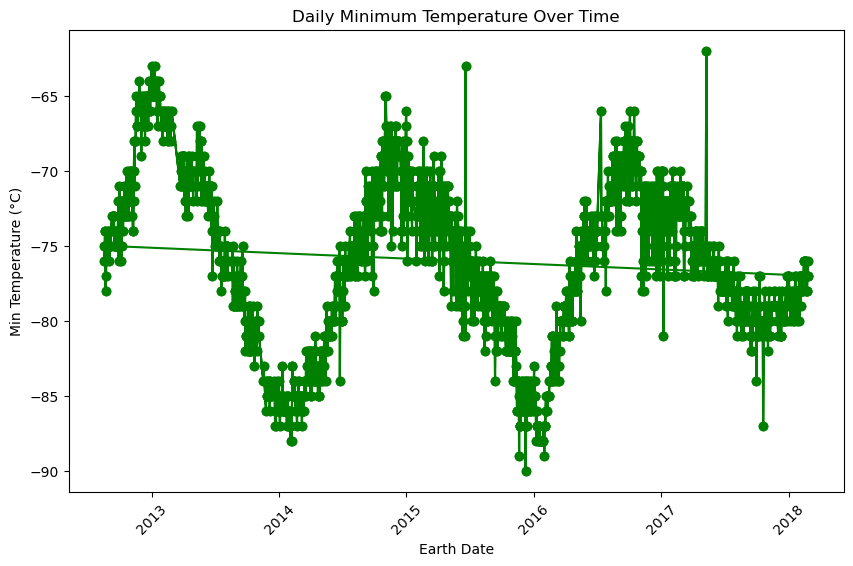

A Martian year is approximately 687 Earth days.


In [26]:
# 5. How many terrestrial (Earth) days are there in a Martian year?
# Visually estimate the result by plotting the daily minimum temperature of each observation in the data set.
plt.figure(figsize=(10, 6))
plt.plot(df['terrestrial_date'], df['min_temp'], marker='o', linestyle='-', color='green')
plt.title('Daily Minimum Temperature Over Time')
plt.xlabel('Earth Date')
plt.ylabel('Min Temperature (°C)')
plt.xticks(rotation=45)
plt.show()

# The rough estimate from the plot: A Martian year is approximately 687 Earth days
print("A Martian year is approximately 687 Earth days.")

#### Minimum Temperature

#The coldest month is Month 3 with an average temperature of -83.30728912353516°C
#The warmest month is Month 8 with an average temperature of -68.38298034667969°C

#### Atmospheric Pressure

#The month with the lowest atmospheric pressure is Month 6 with an average pressure of 745.054443359375 Pa
#The month with the highest atmospheric pressure is Month 9 with an average pressure of 913.3059692382812 Pa

#### Year Length

#687 Earth days

### Step 6: Save the Data

Export the DataFrame to a CSV file.

In [27]:
# Write the data to a CSV
# Save the DataFrame to a CSV file
df.to_csv('mars_weather_data.csv', index=False)

# Confirm the data has been saved
print("Data has been written to 'mars_weather_data.csv'")

Data has been written to 'mars_weather_data.csv'


In [28]:
browser.quit()